In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

TARGET_COLUMN = 'Hair Loss'
FILE_PATH = './dataset/Predict Hair Fall.csv' 

try:
    df = pd.read_csv(FILE_PATH)
    print(f"Successfully loaded data from: {FILE_PATH}")
    print(f"Initial shape: {df.shape}")
except FileNotFoundError:
    print(f"Error: File not found at '{FILE_PATH}'. Please ensure your file path is correct.")
    exit()

# Drop the non-predictive Id column
df = df.drop('Id', axis=1, errors='ignore') 

# --- 1. Encoding and Feature Engineering ---

binary_cols = [
    'Genetics', 
    'Hormonal Changes', 
    'Poor Hair Care Habits ',
    'Environmental Factors', 
    'Smoking', 
    'Weight Loss '
]

for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'Yes': 1, 'No': 0})
        df[col] = df[col].fillna(0).astype(int) 

# One-Hot Encoding
stress_mapping = {'Low': 0, 'Moderate': 1, 'High': 2}
if 'Stress' in df.columns:
    df['Stress'] = df['Stress'].map(stress_mapping)
    df['Stress'] = df['Stress'].fillna(1).astype(int)

multi_value_cols = ['Medical Conditions', 'Nutritional Deficiencies ', 'Medications & Treatments'] 

for col in multi_value_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(r'[\[\]\"]', '', regex=True).fillna('')
        clean_col_name = col.strip().split(" ")[0].capitalize()
        new_count_col = f'Num_{clean_col_name}_Count'
        
        df[new_count_col] = df[col].apply(
            lambda x: len([item.strip() for item in x.split(',') if item.strip() != ''])
        )
        
        df = df.drop(col, axis=1)

if 'Age' in df.columns and 'Genetics' in df.columns and 'Poor Hair Care Habits ' in df.columns and 'Smoking' in df.columns:
    
    df['Age_x_Genetics'] = df['Age'] * df['Genetics']
    df['Smoking_x_PoorHairCare'] = df['Smoking'] * df['Poor Hair Care Habits ']


numerical_cols = ['Age', 'Num_Medical_Count', 'Num_Nutritional_Count', 'Num_Medications_Count', 'Age_x_Genetics'] 
scaler = StandardScaler()

for col in numerical_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mean())
        # Apply scaling
        df[[col]] = scaler.fit_transform(df[[col]])


columns_to_drop_final = [
    # 'Stress', 
    # 'Hormonal Changes', 
    # 'Environmental Factors', 
    'Poor Hair Care Habits ',
    'Smoking',
    'Age'
]

print(f"\n--- Feature Removal: Dropping {len(columns_to_drop_final)} weak features (r < 0.03) ---")
df = df.drop(columns=columns_to_drop_final, errors='ignore')

# Data Split

if TARGET_COLUMN not in df.columns:
    print(f"\nERROR: Target column '{TARGET_COLUMN}' not found. Please check the name.")
    exit()

X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

# Split the data into Training and Testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y 
)

print("\n--- Preprocessing Complete ---")
print(f"Shape of X_train (Features for Training): {X_train.shape}")
print("\nFirst 5 rows of the NEW training data (X_train):")
print(X_train.head())
print("\nVerify that all remaining columns are numerical (0, 1, or scaled floats):")
print(X_train.dtypes)

Successfully loaded data from: ./dataset/Predict Hair Fall.csv
Initial shape: (999, 13)

--- Feature Removal: Dropping 3 weak features (r < 0.03) ---

--- Preprocessing Complete ---
Shape of X_train (Features for Training): (799, 10)

First 5 rows of the NEW training data (X_train):
     Genetics  Hormonal Changes  Stress  Environmental Factors  Weight Loss   \
761         0                 1       1                      0             1   
77          0                 1       2                      0             1   
813         1                 1       2                      0             1   
756         1                 1       1                      0             0   
975         1                 1       2                      1             0   

     Num_Medical_Count  Num_Nutritional_Count  Num_Medications_Count  \
761                0.0                    0.0                    0.0   
77                 0.0                    0.0                    0.0   
813                

Training Logistic Regression Model...
Training complete.

## 📈 Classification Report (Test Set) ##
              precision    recall  f1-score   support

           0       0.46      0.42      0.44       101
           1       0.46      0.51      0.48        99

    accuracy                           0.46       200
   macro avg       0.46      0.46      0.46       200
weighted avg       0.46      0.46      0.46       200

ROC-AUC Score: 0.4426

Confusion Matrix:
[[42 59]
 [49 50]]

## 🧠 Model Interpretation: Feature Coefficients ##
Top 5 Most Impactful Features:
Genetics                  0.541130
Weight Loss               0.332443
Age_x_Genetics           -0.186512
Smoking_x_PoorHairCare   -0.182951
Stress                   -0.018899
dtype: float64


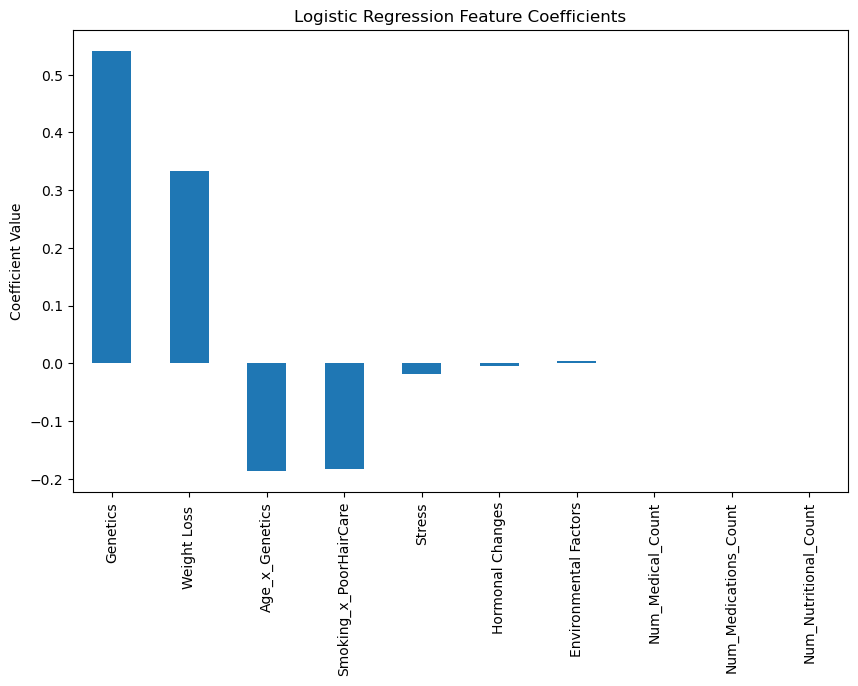

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Model Instantiation and Training ---

# 1.1 Instantiate the Logistic Regression Model
# random_state ensures reproducibility
# C=1.0 is the default inverse of regularization strength
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') 

print("Training Logistic Regression Model...")
# 1.2 Train the model on the training data
log_reg_model.fit(X_train, y_train)

print("Training complete.")


# --- 2. Prediction and Evaluation ---

# 2.1 Predict classes on the test set
y_pred = log_reg_model.predict(X_test)

# 2.2 Predict probabilities (needed for ROC-AUC)
# .predict_proba() returns probabilities for class 0 and class 1. We want class 1.
y_pred_proba = log_reg_model.predict_proba(X_test)[:, 1]


# 2.3 Calculate Key Metrics

# Classification Report (Precision, Recall, F1-Score, Accuracy)
print("\n## 📈 Classification Report (Test Set) ##")
print(classification_report(y_test, y_pred))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)


# --- 3. Interpretation: Feature Importance ---

# Logistic Regression provides feature importance via its coefficients
print("\n## 🧠 Model Interpretation: Feature Coefficients ##")

# Map feature names to their corresponding coefficient values
feature_names = X_train.columns
coefficients = log_reg_model.coef_[0]

# Create a Series for easy viewing and sorting
coef_df = pd.Series(coefficients, index=feature_names)

# Sort coefficients by absolute value to see the most impactful features
coef_df_sorted = coef_df.reindex(coef_df.abs().sort_values(ascending=False).index)

print("Top 5 Most Impactful Features:")
print(coef_df_sorted.head(5))

# Plot the coefficients for visualization
plt.figure(figsize=(10, 6))
coef_df_sorted.plot(kind='bar')
plt.title('Logistic Regression Feature Coefficients')
plt.ylabel('Coefficient Value')
plt.show()

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report

print("--- Starting Random Forest Modeling ---")

# 1. Hyperparameter Tuning (Grid Search)
# Define the parameter grid to search
param_grid_rf = {
    'n_estimators': [100, 200],         # Number of trees in the forest
    'max_depth': [10, 20, None],       # Maximum depth of the tree
    'min_samples_leaf': [1, 2]         # Minimum number of samples required to be at a leaf node
}

# Use GridSearchCV with 5-fold cross-validation
# We prioritize 'roc_auc' as the scoring metric
grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42), 
    param_grid_rf, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)

# Get the best estimator
best_rf = grid_search_rf.best_estimator_
print(f"Best Random Forest Parameters: {grid_search_rf.best_params_}")

# 2. Evaluation
y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]

print("\n## 📈 Random Forest Classification Report (Test Set) ##")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

--- Starting Random Forest Modeling ---
Best Random Forest Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 200}

## 📈 Random Forest Classification Report (Test Set) ##
              precision    recall  f1-score   support

           0       0.57      0.50      0.53       101
           1       0.55      0.61      0.57        99

    accuracy                           0.56       200
   macro avg       0.56      0.56      0.55       200
weighted avg       0.56      0.56      0.55       200

ROC-AUC Score: 0.5504


In [12]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV

print("\n--- Starting XGBoost Modeling ---")

# 1. Hyperparameter Tuning (Randomized Search is faster for complex models)
param_dist_xgb = {
    'n_estimators': [100, 300, 500],   # Number of boosting rounds
    'learning_rate': [0.01, 0.1, 0.3], # Step size shrinkage
    'max_depth': [3, 5, 7],            # Maximum tree depth
    'colsample_bytree': [0.7, 0.9, 1.0] # Subsample ratio of columns when constructing each tree
}

# Use RandomizedSearchCV
random_search_xgb = RandomizedSearchCV(
    xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    param_dist_xgb,
    n_iter=10, # Number of parameter settings that are sampled
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

random_search_xgb.fit(X_train, y_train)

# Get the best estimator
best_xgb = random_search_xgb.best_estimator_
print(f"Best XGBoost Parameters: {random_search_xgb.best_params_}")

# 2. Evaluation
y_pred_xgb = best_xgb.predict(X_test)
y_pred_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("\n## 📈 XGBoost Classification Report (Test Set) ##")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")


--- Starting XGBoost Modeling ---
Best XGBoost Parameters: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

## 📈 XGBoost Classification Report (Test Set) ##
              precision    recall  f1-score   support

           0       0.57      0.58      0.58       101
           1       0.56      0.55      0.55        99

    accuracy                           0.56       200
   macro avg       0.56      0.56      0.56       200
weighted avg       0.56      0.56      0.56       200

ROC-AUC Score: 0.5697


c:\Users\Hooman\anaconda3\envs\introToMLenv\lib\site-packages\xgboost\training.py:199: UserWarning: [16:58:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [13]:
from sklearn.neighbors import KNeighborsClassifier

print("\n--- Starting K-Nearest Neighbors Modeling ---")

# 1. Hyperparameter Tuning (Grid Search for K)
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11], # The number of neighbors to consider (k)
    'weights': ['uniform', 'distance'] # Weighting function used in prediction
}

grid_search_knn = GridSearchCV(
    KNeighborsClassifier(), 
    param_grid_knn, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1
)

grid_search_knn.fit(X_train, y_train)

# Get the best estimator
best_knn = grid_search_knn.best_estimator_
print(f"Best KNN Parameters: {grid_search_knn.best_params_}")

# 2. Evaluation
y_pred_knn = best_knn.predict(X_test)
y_pred_proba_knn = best_knn.predict_proba(X_test)[:, 1]

print("\n## 📈 KNN Classification Report (Test Set) ##")
print(classification_report(y_test, y_pred_knn))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_knn):.4f}")


--- Starting K-Nearest Neighbors Modeling ---
Best KNN Parameters: {'n_neighbors': 7, 'weights': 'distance'}

## 📈 KNN Classification Report (Test Set) ##
              precision    recall  f1-score   support

           0       0.59      0.53      0.56       101
           1       0.56      0.62      0.59        99

    accuracy                           0.57       200
   macro avg       0.58      0.58      0.57       200
weighted avg       0.58      0.57      0.57       200

ROC-AUC Score: 0.6008


In [14]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report

print("--- Starting Support Vector Machine (SVM) Modeling ---")

# 1. Hyperparameter Tuning (Grid Search)
# Define the parameter grid to search
param_grid_svm = {
    # C: Regularization parameter. Smaller C means stronger regularization.
    'C': [0.1, 1.0, 10], 
    
    # kernel: Specifies the kernel type to be used in the algorithm.
    'kernel': ['rbf', 'linear'], # RBF is often good for non-linear boundaries.
    
    # gamma: Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.
    # 'scale' uses 1 / (n_features * X.var()) - a good default.
    'gamma': ['scale', 0.1, 1] 
}

# Use GridSearchCV with 5-fold cross-validation
# We prioritize 'roc_auc' as the scoring metric
grid_search_svm = GridSearchCV(
    SVC(probability=True, random_state=42), # probability=True is needed for ROC-AUC
    param_grid_svm, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1
)

grid_search_svm.fit(X_train, y_train)

# Get the best estimator
best_svm = grid_search_svm.best_estimator_
print(f"Best SVM Parameters: {grid_search_svm.best_params_}")

# 2. Evaluation
y_pred_svm = best_svm.predict(X_test)

# Predict probabilities (needed for ROC-AUC)
# Use .predict_proba() on the best estimator
y_pred_proba_svm = best_svm.predict_proba(X_test)[:, 1]

# 3. Calculate Key Metrics
print("\n## 📈 SVM Classification Report (Test Set) ##")
print(classification_report(y_test, y_pred_svm))

# ROC-AUC Score
roc_auc_svm = roc_auc_score(y_test, y_pred_proba_svm)
print(f"ROC-AUC Score: {roc_auc_svm:.4f}")

--- Starting Support Vector Machine (SVM) Modeling ---
Best SVM Parameters: {'C': 10, 'gamma': 1, 'kernel': 'rbf'}

## 📈 SVM Classification Report (Test Set) ##
              precision    recall  f1-score   support

           0       0.57      0.45      0.50       101
           1       0.54      0.66      0.59        99

    accuracy                           0.55       200
   macro avg       0.55      0.55      0.55       200
weighted avg       0.55      0.55      0.55       200

ROC-AUC Score: 0.5448


In [15]:
import pandas as pd
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score

# --- 1. Function to Calculate All Metrics ---
def evaluate_model(y_true, y_pred, y_proba, model_name):
    """Calculates and returns a dictionary of key classification metrics."""
    # Note: We use 'pos_label=1' to ensure metrics are for the 'Hair Loss' class.
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1 Score (Class 1)': f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        'ROC-AUC Score': roc_auc_score(y_true, y_proba),
        'Precision (Class 1)': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'Recall (Class 1)': recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    }

# --- 2. Gather Results from All Models ---

results = []

# Gather results for all five models
results.append(evaluate_model(y_test, y_pred, y_pred_proba, 'Logistic Regression'))
results.append(evaluate_model(y_test, y_pred_rf, y_pred_proba_rf, 'Random Forest'))
results.append(evaluate_model(y_test, y_pred_xgb, y_pred_proba_xgb, 'XGBoost'))
results.append(evaluate_model(y_test, y_pred_knn, y_pred_proba_knn, 'KNN'))
results.append(evaluate_model(y_test, y_pred_svm, y_pred_proba_svm, 'SVM'))
# results.append(evaluate_model(y_test, y_pred_nn, y_pred_proba_nn, 'Neural Network (MLP)'))

# --- 3. Create and Display the Comparison Table ---

comparison_df = pd.DataFrame(results)

# Round the numerical scores for cleaner presentation
numerical_cols = ['Accuracy', 'F1 Score (Class 1)', 'ROC-AUC Score', 'Precision (Class 1)', 'Recall (Class 1)']
comparison_df[numerical_cols] = comparison_df[numerical_cols].round(4)

# Sort the table by the key evaluation metric (ROC-AUC is typically preferred for model comparison)
comparison_df_sorted = comparison_df.sort_values(by='ROC-AUC Score', ascending=False)

print("\n## 🥇 Final Comprehensive Model Comparison on Test Set 🥇")
print("---")
print(comparison_df_sorted)
print("---")


## 🥇 Final Comprehensive Model Comparison on Test Set 🥇
---
                 Model  Accuracy  F1 Score (Class 1)  ROC-AUC Score  \
3                  KNN     0.575              0.5894         0.6008   
2              XGBoost     0.565              0.5538         0.5697   
1        Random Forest     0.555              0.5742         0.5504   
4                  SVM     0.550              0.5909         0.5448   
0  Logistic Regression     0.460              0.4808         0.4426   

   Precision (Class 1)  Recall (Class 1)  
3               0.5648            0.6162  
2               0.5625            0.5455  
1               0.5455            0.6061  
4               0.5372            0.6566  
0               0.4587            0.5051  
---


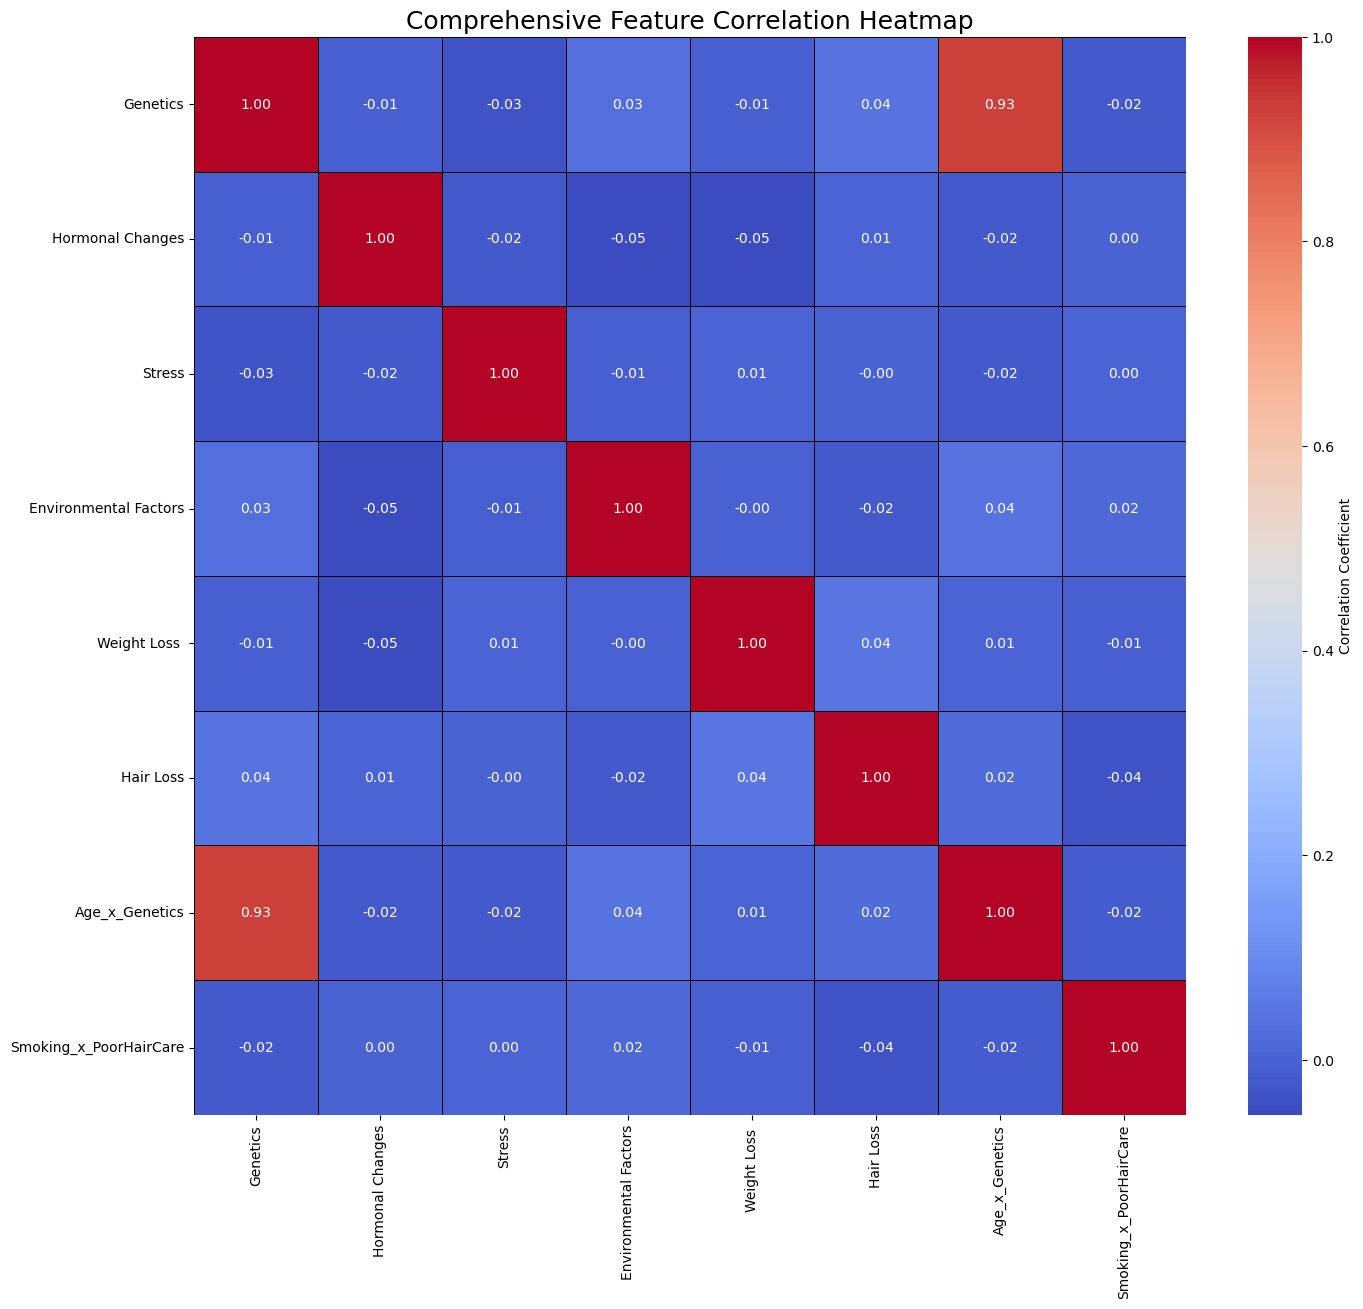


Feature Correlation with Target (Hair Loss) ##
Weight Loss               0.0448
Genetics                  0.0413
Age_x_Genetics            0.0202
Hormonal Changes          0.0071
Stress                   -0.0000
Environmental Factors    -0.0189
Smoking_x_PoorHairCare   -0.0360


In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

TARGET_COLUMN = 'Hair Loss'
COLUMNS_TO_REMOVE = ['Num_Medical_Count', 'Num_Nutritional_Count', 'Num_Medications_Count']

def generate_correlation_heatmap(df, target_column):
    df_processed = df.drop(columns=COLUMNS_TO_REMOVE, errors='ignore')
    df_corr = df_processed.apply(pd.to_numeric, errors='coerce')

    df_corr = df_corr.fillna(df_corr.mean())

    if target_column not in df_corr.columns:
        print(f"\nERROR: Target column '{target_column}' not found. Cannot proceed.")
        return

    correlation_matrix = df_corr.corr()

    plt.figure(figsize=(16, 14))
    sns.heatmap(
        correlation_matrix,
        annot=True,            
        cmap='coolwarm',
        fmt=".2f",
        linewidths=.5,
        linecolor='black',
        cbar_kws={'label': 'Correlation Coefficient'}
    )
    plt.title('Comprehensive Feature Correlation Heatmap', fontsize=18)
    plt.show()

    target_corr = correlation_matrix[target_column].drop(target_column).sort_values(ascending=False).round(4)
    print("\nFeature Correlation with Target (Hair Loss) ##")
    print(target_corr.to_string())

generate_correlation_heatmap(df, TARGET_COLUMN)